# Optimising a btm site with solar, battery, load, and
In this example we will build the echo model from the fundamental components, add an objective, and optimise the controllable elements. In this case, the controllable elements are the battery charging/discharging.

## Import required modules

In [1]:
import numpy as np
from echo.echo_models import *
from echo.echo_optimiser import *
from echo.objectives import *

## Define model parameters


In [2]:
time_periods = 96  # total number of intervals
interval_duration = 15  # Duration in mins of each interval
expansion_periods = 1  # Number of planning intervals - in echo V1, set to 1 always

## Define data as arrays
These can either be defined as lists or numpy arrays

In [3]:
load_array = np.array(
    [2.13, 2.09, 2.3, 2.11, 2.2, 2.23, 15, 15, 15, 2.19, 2.19, 2.19, 2.12, 2.15, 2.25, 2.12, 2.21, 2.16,
     2.26, 2.13, 2.08, 2.15, 2.42, 2.02, 2.3, 2.26, 2.35, 2.55, 3.23, 2.98, 3.49, 3.5, 3.12, 3.52, 3.94, 3.55,
     3.99, 3.71, 3.38, 3.76, 3.71, 3.78, 3.29, 3.65, 3.61, 3.75, 3.38, 3.66, 3.56, 3.69, 3.3, 3.61, 3.71, 3.82,
     3.17, 3.69, 3.74, 3.86, 3.57, 3.55, 3.75, 3.6, 3.67, 3.48, 3.51, 3.46, 3.19, 3.38, 3.19, 3.38, 3.04, 3.12,
     2.91, 3.11, 3.13, 2.77, 2.24, 2.54, 2.24, 2.24, 2.09, 2.33, 2.17, 2.16, 1.97, 2.16, 2.21, 2.18, 2.01, 2.16,
     2.19, 2.11, 2.17, 2.13, 12, 12])

pv_array = 2 * np.array(
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.05, 0.23, 0.52,
     0.74, 0.71, 0.63, 0.68, 0.97, 0.01, 0.52, 0.83, 0.83, 0.79, 1.22, 1.36, 1.27, 1.42, 1.97, 2.56, 2.91, 3.24,
     3.8, 4.3, 4.62, 4.84, 4.6, 4.17, 3.77, 3.76, 3.38, 2.64, 1.96, 1.76, 1.85, 2.4, 3.82, 5.13, 4.97, 5.02, 5.43,
     5.32, 3.56, 1.75, 1.43, 1.65, 1.69, 2.3, 2.71, 2.41, 2.63, 2.6, 1.9, 0.78, 0.13, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,
     0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

pv_array *= -1  # use positive load convention, so solar gen is negative

## Instantiate an echo optimisation graph

In [4]:
system = OptimisationGraph()

### Create grid node

In [5]:
grid = Node() # create node representing upstream grid
grid.add_named_electrical_ports(['grid'])

### Create connection point node

In [6]:
connection_point = ElectricalTellegenNode()     # create the connection point node
connection_point.add_named_electrical_ports(['load', 'inv', 'grid'])  # add ports with easily referenced names

### Create load node
Load nodes typically have a single port.

In [7]:
load = Node()                       # create a node to represent the load
load_port = ElectricalDemand()             # create an electrical demand port to attach to this node
load_port.add_demand_profile_from_array(load_array, expansion_periods)
load.ports['load'] = load_port # explicitly add the load_port to the dictionary of node ports

### Create inverter node
An inverter is a special node type that has methods for adding ports to either the ac or dc side. This is how the inverter manages orientation and losses.

In [8]:
inverter = Inverter(max_import=None,
                    max_export=None,
                    dc_ac_efficiency=1,
                    ac_dc_efficiency=1)

inverter.add_ac_port('inv')     # add a port with name 'inv' that is used to connect upstream/ac side
inverter.add_dc_port('battery')    # add a port with name 'battery' to connect to the battery
inverter.add_dc_port('pv')      # add a port with name 'pv' for us to connect the pv node into

### Create battery node

In [9]:
# create a node for the battery
battery = Node()
# create an electrical storage object
battery_port = ElectricalStorage(max_capacity=15.0,                # max capacity of battery in kwh
                       depth_of_discharge_limit=0,      # allowable depth of discharge in range [0,100] (i.e. percent)
                       charging_power_limit=1.25,       # max charging rate in kW
                       discharging_power_limit=-1.25,   # max discharging rate in kW
                       charging_efficiency=1,           # charging efficiency in range [0,1]
                       discharging_efficiency=1,        # discharging efficiency in range [0,1]
                       initial_state_of_charge=0.0)     # initial state of charge in kWh

battery.ports['battery'] = battery_port

### Create solar node
A solar node usually has a single port.

In [10]:
# create a node for the solar
solar = Node()
solar_port = ElectricalGeneration()     # create an electrical generation object
solar_port.curtailable = False          # set whether this can be curtailed or not
solar_port.add_generation_profile_from_array(pv_array, expansion_periods)
solar.ports['pv'] = solar_port        # add the solar port to the dictionary of node ports

### Add all nodes to the graph

In [11]:
system.add_node_obj([grid, connection_point, load, inverter, solar, battery])  # nodes can be added one by one or as a list

### Make connections between ports on nodes
This does two things - it creates an edge object for each edge, and it adds that edge object to the optimisation graph.

In [12]:
# Add edges to graph
system.connect_ports_and_create_edge(grid.ports['grid'], connection_point.ports['grid'])
system.connect_ports_and_create_edge(connection_point.ports['load'], load.ports['load'])
system.connect_ports_and_create_edge(connection_point.ports['inv'], inverter.ports['inv'])
system.connect_ports_and_create_edge(inverter.ports['battery'], battery.ports['battery'])
system.connect_ports_and_create_edge(inverter.ports['pv'], solar.ports['pv'])

## Create objectives
Here we will create an import tariff and export tariff. These tariffs are echo objects.

## Define tariff arrays

In [13]:
# Tariffs are in $ / kWh
import_tariff_array = np.array(([0.1] * 28 + [0.3] * 8 + [0.2] * 32 + [0.3] * 16 + [0.1] * 12))
export_tariff_array = np.array(([0.0] * 96))

### Create echo objective set

In [14]:
# First create the tariffs as echo objects
import_cost = ImportTariff(component=connection_point.ports['grid'],
                           tariff_array=import_tariff_array,
                           expansion_periods=expansion_periods)  # create the import objective cost

export_cost = ExportTariff(component=connection_point.ports['grid'],
                           tariff_array=export_tariff_array,
                           expansion_periods=expansion_periods)  # create the export objective cost

# Then define the objective set, which is just a list with the two costs
objective_set = ObjectiveSet(objective_list=[import_cost, export_cost])


## Run the optimiser

In [15]:
# Invoke the optimiser
optimiser = EchoOptimiser(interval_duration=interval_duration,
                          number_of_intervals=time_periods,
                          number_of_expansion_intervals=expansion_periods,
                          discount_rate=0,
                          ES=system,
                          objective_set=objective_set,
                          optimiser_engine='cplex')

# Optimise
optimiser.optimise()

## Plot some results

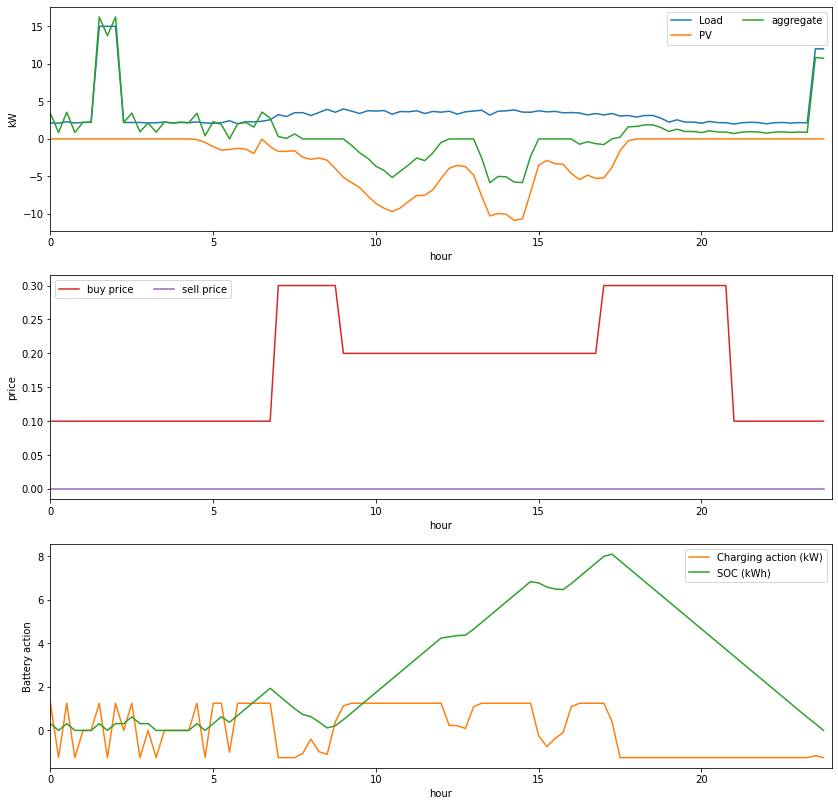

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get optimised results
# These are retrieved by calling the optimiser .values() method, and providing the variable name we want.
# In this case, the storage port has two variables of interest - port_name, which is the battery power, and soc_value

storage_energy_delta = optimiser.values(battery_port.port_name, 0)
storage_energy_soc = optimiser.values(battery_port.soc_value, 0)
optimised_connection_point_load = optimiser.values(connection_point.ports['grid'].port_name, 0)


# Do plotting
colors = sns.color_palette()
hrs = np.arange(0, len(load_array)) / 4
fig = plt.figure(figsize=(14, 14))
ax1 = fig.add_subplot(3, 1, 1)
line1, = ax1.plot(hrs, load_array, color=colors[0])
line2, = ax1.plot(hrs, pv_array, color=colors[1])
line3, = ax1.plot(hrs, optimised_connection_point_load, color=colors[2])
ax1.set_xlabel('hour'), ax1.set_ylabel('kW')
ax1.legend([line1, line2, line3], ['Load', 'PV', 'aggregate'], ncol=2)
ax1.set_xlim([0, len(load_array) / 4])

ax2 = fig.add_subplot(3, 1, 2)
line1, = ax2.plot(hrs, import_tariff_array, color=colors[3])
line2, = ax2.plot(hrs, export_tariff_array, color=colors[4])
ax2.set_xlabel('hour'), ax2.set_ylabel('price')
ax2.legend([line1, line2], ['buy price', 'sell price'], ncol=2)
ax2.set_xlim([0, len(load_array) / 4])

ax3 = fig.add_subplot(3, 1, 3)
line1, = ax3.plot(hrs, storage_energy_delta, color=colors[1])
line2, = ax3.plot(hrs, storage_energy_soc, color=colors[2])
ax3.set_xlim([0, len(load_array) / 4])
ax3.set_xlabel('hour'), ax3.set_ylabel('Battery action')
ax3.legend([line1, line2], ['Charging action (kW)', 'SOC (kWh)'])
plt.show()
